In [1]:
#Importing libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler


In [2]:
# Mount Google Drive (Safe for both Colab and Local)
import os
try:
    from google.colab import drive
    if not os.path.exists('/content/drive'):
        drive.mount('/content/drive')
    else:
        print('Google Drive is already mounted.')
    drive_mounted = True
except Exception:
    drive_mounted = False
    print('Running locally: Google Drive mount skipped.')


Running locally: Google Drive mount skipped.


In [3]:
# Load dataset
import os
import pandas as pd

colab_path = '/content/drive/MyDrive/ML Project/Insurance_Fraud_Dataset_100K_Realistic.xlsx'
local_path = 'Insurance_Fraud_Dataset_100K_Realistic.xlsx'

if os.path.exists(colab_path):
    file_path = colab_path
elif os.path.exists(local_path):
    file_path = local_path
else:
    file_path = local_path

print(f'Loading dataset from: {file_path}')
df = pd.read_excel(file_path)
print(f'Dataset loaded successfully! Shape: {df.shape}')


Loading dataset from: Insurance_Fraud_Dataset_100K_Realistic.xlsx
Dataset loaded successfully! Shape: (100000, 35)


In [4]:
df.head()

,claim_id,customer_age,months_as_customer,previous_claims,previous_fraud_history,insured_sex,insured_education_level,insured_occupation,insured_relationship,policy_state,...,bodily_injuries,witnesses,police_report_available,injury_claim,property_claim,vehicle_claim,claim_amount,auto_make,auto_model,auto_year
0,CLM000001,21,88,2,0,MALE,Associate,Teacher,Child,TX,...,0,0,YES,1750,12723,36140,50613,Honda,B,2012
1,CLM000002,68,124,0,0,MALE,PhD,Technician,Other,TX,...,2,0,YES,1704,10297,23509,35510,Tesla,C,2013
2,CLM000003,39,23,2,0,FEMALE,High School,Doctor,Married,CA,...,1,0,YES,26017,11313,2068,39398,Toyota,B,2022
3,CLM000004,30,131,0,0,FEMALE,High School,Engineer,Parent,OH,...,1,2,YES,14274,311,8118,22703,Toyota,B,2021
4,CLM000005,22,100,5,0,FEMALE,Associate,Technician,Child,NY,...,1,5,YES,27525,20862,4745,53132,Toyota,C,2022


In [5]:
#Checking missing values
df.isnull().sum()

claim_id                           0
customer_age                       0
months_as_customer                 0
previous_claims                    0
previous_fraud_history             0
insured_sex                        0
insured_education_level            0
insured_occupation                 0
insured_relationship               0
policy_state                       0
policy_csl                         0
policy_deductable                  0
policy_annual_premium              0
umbrella_limit                     0
capital_gains                      0
capital_loss                       0
incident_type                      0
collision_type                     0
incident_severity                  0
authorities_contacted          24974
incident_state                     0
incident_city                      0
incident_hour_of_the_day           0
number_of_vehicles_involved        0
property_damage                    0
bodily_injuries                    0
witnesses                          0
p

In [6]:
#handling missing values by filling with "Unknown"
df['authorities_contacted'] = df['authorities_contacted'].fillna('Unknown')

In [7]:
df.head()

,claim_id,customer_age,months_as_customer,previous_claims,previous_fraud_history,insured_sex,insured_education_level,insured_occupation,insured_relationship,policy_state,...,bodily_injuries,witnesses,police_report_available,injury_claim,property_claim,vehicle_claim,claim_amount,auto_make,auto_model,auto_year
0,CLM000001,21,88,2,0,MALE,Associate,Teacher,Child,TX,...,0,0,YES,1750,12723,36140,50613,Honda,B,2012
1,CLM000002,68,124,0,0,MALE,PhD,Technician,Other,TX,...,2,0,YES,1704,10297,23509,35510,Tesla,C,2013
2,CLM000003,39,23,2,0,FEMALE,High School,Doctor,Married,CA,...,1,0,YES,26017,11313,2068,39398,Toyota,B,2022
3,CLM000004,30,131,0,0,FEMALE,High School,Engineer,Parent,OH,...,1,2,YES,14274,311,8118,22703,Toyota,B,2021
4,CLM000005,22,100,5,0,FEMALE,Associate,Technician,Child,NY,...,1,5,YES,27525,20862,4745,53132,Toyota,C,2022


In [8]:
# Re-checking missing values if any of them left or not
df.isnull().sum()

claim_id                       0
customer_age                   0
months_as_customer             0
previous_claims                0
previous_fraud_history         0
insured_sex                    0
insured_education_level        0
insured_occupation             0
insured_relationship           0
policy_state                   0
policy_csl                     0
policy_deductable              0
policy_annual_premium          0
umbrella_limit                 0
capital_gains                  0
capital_loss                   0
incident_type                  0
collision_type                 0
incident_severity              0
authorities_contacted          0
incident_state                 0
incident_city                  0
incident_hour_of_the_day       0
number_of_vehicles_involved    0
property_damage                0
bodily_injuries                0
witnesses                      0
police_report_available        0
injury_claim                   0
property_claim                 0
vehicle_cl

In [9]:
# Checking duplicates if any
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [10]:
df.info()     #Dataset column labels

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 35 columns):
 #   Column                       Non-Null Count   Dtype
---  ------                       --------------   -----
 0   claim_id                     100000 non-null  str  
 1   customer_age                 100000 non-null  int64
 2   months_as_customer           100000 non-null  int64
 3   previous_claims              100000 non-null  int64
 4   previous_fraud_history       100000 non-null  int64
 5   insured_sex                  100000 non-null  str  
 6   insured_education_level      100000 non-null  str  
 7   insured_occupation           100000 non-null  str  
 8   insured_relationship         100000 non-null  str  
 9   policy_state                 100000 non-null  str  
 10  policy_csl                   100000 non-null  str  
 11  policy_deductable            100000 non-null  int64
 12  policy_annual_premium        100000 non-null  int64
 13  umbrella_limit               100000 non-n

In [11]:
#Finding categorical columns
categorical_cols = df.select_dtypes(include='object').columns
print(categorical_cols)

Index(['claim_id', 'insured_sex', 'insured_education_level',
       'insured_occupation', 'insured_relationship', 'policy_state',
       'policy_csl', 'incident_type', 'collision_type', 'incident_severity',
       'authorities_contacted', 'incident_state', 'incident_city',
       'property_damage', 'police_report_available', 'auto_make',
       'auto_model'],
      dtype='str')


C:\Users\DELL\AppData\Local\Temp\ipykernel_9852\373263208.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


In [12]:
#Dropping unnecessary columns
if "claim_id" in df.columns:
    df = df.drop(columns=["claim_id"])

print("claim_id removed successfully.")
print("Dataset shape:", df.shape)

claim_id removed successfully.
Dataset shape: (100000, 34)


In [13]:
y = df['previous_fraud_history']
X = df.drop('previous_fraud_history', axis=1)

# Splitting of training and testing set
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training data: (80000, 33)
Testing data: (20000, 33)
Training target: (80000,)
Testing target: (20000,)


In [14]:
#Identify numerical and categorical features
numeric_features = X_train.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['customer_age', 'months_as_customer', 'previous_claims', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'capital_gains', 'capital_loss', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'injury_claim', 'property_claim', 'vehicle_claim', 'claim_amount', 'auto_year']

Categorical features:
['insured_sex', 'insured_education_level', 'insured_occupation', 'insured_relationship', 'policy_state', 'policy_csl', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'property_damage', 'police_report_available', 'auto_make', 'auto_model']


C:\Users\DELL\AppData\Local\Temp\ipykernel_9852\405940197.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


In [15]:
# Build Preprocessing Pipeline
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
#The missing numerical values are replaced with median of the column
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)
# The missing categorical values are replaced by most frequent values
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [16]:
#Transform Training and Testing Data: sending the result to the next stage
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (80000, 93)
Processed testing shape: (20000, 93)


In [17]:
# Checking class imbalance: counts number of samples belonging to each class
print(y_train.value_counts())
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("Scale Pos Weight:", scale_pos_weight)

previous_fraud_history
0    76019
1     3981
Name: count, dtype: int64
Scale Pos Weight: 19.09545340366742


In [18]:
# Training XGBoost Teacher Model
!pip install -q xgboost
from xgboost import XGBClassifier
teacher = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight
)


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\DELL\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [19]:
# Training the teacher model(It predicts the fraud probabilities for training the data)
import time
start_time = time.time()                   #Recording the starting time
teacher.fit(
    X_train_processed,      #Input
    y_train           #Target
)

teacher_train_time = time.time() - start_time

print("Teacher training time:", teacher_train_time, "seconds")

Teacher training time: 3.5130808353424072 seconds


In [20]:
# Teacher Predictions
teacher_pred = teacher.predict(X_test_processed)

teacher_prob = teacher.predict_proba(
    X_test_processed
)[:, 1]

In [21]:
#Evaluation Metrics : measures how well model performs
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [22]:
# Checking the teacher model accuracy
teacher_accuracy = accuracy_score(
    y_test,
    teacher_pred
)

teacher_precision = precision_score(
    y_test,
    teacher_pred,
    zero_division=0
)

teacher_recall = recall_score(
    y_test,
    teacher_pred,
    zero_division=0
)

teacher_f1 = f1_score(
    y_test,
    teacher_pred,
    zero_division=0
)

teacher_auc = roc_auc_score(
    y_test,
    teacher_prob
)

print("TEACHER MODEL:")
print("Accuracy :", teacher_accuracy)
print("Precision:", teacher_precision)
print("Recall   :", teacher_recall)
print("F1 Score :", teacher_f1)
print("ROC-AUC  :", teacher_auc)

TEACHER MODEL:
Accuracy : 0.8398
Precision: 0.05301497369486038
Recall   : 0.13165829145728644
F1 Score : 0.07559145989613388
ROC-AUC  : 0.5017919378529057


In [23]:
#Statistical criteria
print(
    classification_report(
        y_test,
        teacher_pred,
        target_names=["Genuine", "Fraud"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     Genuine       0.95      0.88      0.91     19005
       Fraud       0.05      0.13      0.08       995

    accuracy                           0.84     20000
   macro avg       0.50      0.50      0.49     20000
weighted avg       0.91      0.84      0.87     20000



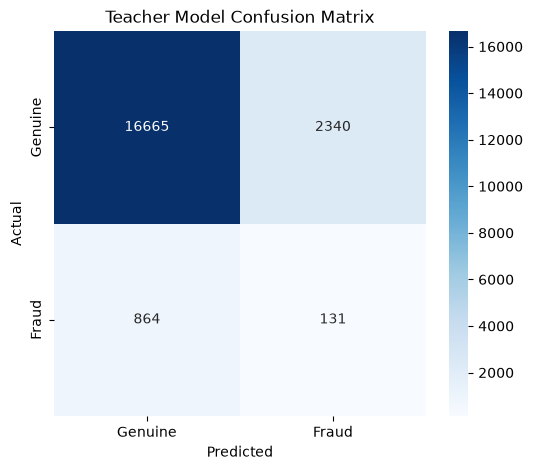

In [24]:
#Teacher Model Confusion Matrix : table used to measure how well model is performing
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    y_test,
    teacher_pred
)
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Genuine", "Fraud"],
    yticklabels=["Genuine", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Teacher Model Confusion Matrix")
plt.show()

In [25]:
#Generate teacher soft label : (probabilities from training data are called soft labels)
teacher_train_prob = teacher.predict_proba(
    X_train_processed
)[:, 1]

print(teacher_train_prob[:10])

[0.2883633  0.3882653  0.37927067 0.28008288 0.49409032 0.32794216
 0.344207   0.37036818 0.1235491  0.31569773]


In [26]:
# Converting processed data to dense format safely
from scipy import sparse
import numpy as np

if sparse.issparse(X_train_processed):
    X_train_dense = X_train_processed.toarray().astype(np.float32)
else:
    X_train_dense = np.asarray(X_train_processed).astype(np.float32)

if sparse.issparse(X_test_processed):
    X_test_dense = X_test_processed.toarray().astype(np.float32)
else:
    X_test_dense = np.asarray(X_test_processed).astype(np.float32)

y_train_np = y_train.to_numpy().astype(np.float32)
y_test_np = y_test.to_numpy().astype(np.float32)
teacher_train_prob_np = teacher_train_prob.astype(np.float32)

print('X_train dense shape:', X_train_dense.shape)
print('X_test dense shape :', X_test_dense.shape)
print('y_train shape      :', y_train_np.shape)
print('y_test shape       :', y_test_np.shape)


X_train dense shape: (80000, 93)
X_test dense shape : (20000, 93)
y_train shape      : (80000,)
y_test shape       : (20000,)


In [27]:
# Data preparation check
print(f'Ready for PyTorch training on {X_train_dense.shape[0]} samples with {X_train_dense.shape[1]} features.')


Ready for PyTorch training on 80000 samples with 93 features.


In [28]:
import torch
import torch.nn as nn  #nn-->neural network functionality
from torch.utils.data import TensorDataset, DataLoader

#STUDENT TRAINING DATA
#converting the training features into PyTorch tensor
#Tensors: multi-dimensional array used to store and process data
X_train_tensor = torch.tensor(
    X_train_dense,
    dtype=torch.float32
).clone().detach()

y_train_tensor = torch.tensor(
    y_train_np,
    dtype=torch.float32
).clone().detach()

#Converting teacher probabilities into tensors
teacher_train_prob_tensor = torch.tensor(
    teacher_train_prob_np,
    dtype=torch.float32
).clone().detach()

# Creating dataset
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor,
    teacher_train_prob_tensor
)

# Creating DataLoader
#DataLoader:manages how data is fed into a model during training
train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True
)

# Check sizes
print("X training:", X_train_tensor.shape)
print("Y training:", y_train_tensor.shape)
print("Teacher probabilities:", teacher_train_prob_tensor.shape)
print("Total training samples:", len(train_dataset))

X training: torch.Size([80000, 93])
Y training: torch.Size([80000])
Teacher probabilities: torch.Size([80000])
Total training samples: 80000


In [29]:
input_size = X_train_dense.shape[1]

class StudentModel(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x).squeeze(1)


student = StudentModel(input_size)

print(student)

StudentModel(
  (network): Sequential(
    (0): Linear(in_features=93, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [30]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using:", device)

student = student.to(device)

Using: cpu


In [31]:
#Knowledge Distillation
temperature = 4.0
alpha = 0.5

optimizer = torch.optim.Adam(
    student.parameters(),
    lr=0.001
)

hard_loss_function = nn.BCEWithLogitsLoss()

In [32]:
#Train student using Distillation
epochs = 15

student.train()

for epoch in range(epochs):

    total_loss = 0

    for batch_X, batch_y, batch_teacher_prob in train_loader:

        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        batch_teacher_prob = batch_teacher_prob.to(device)

        optimizer.zero_grad()

        # Student prediction
        student_logits = student(batch_X)

        # 1. Hard-label loss
        hard_loss = hard_loss_function(
            student_logits,
            batch_y
        )


        # 2. Soft-label loss
        # Prevent log(0)
        eps = 1e-7
        teacher_logits = torch.log(
            (batch_teacher_prob + eps) /
            (1 - batch_teacher_prob + eps)
        )

        teacher_soft = torch.sigmoid(
            teacher_logits / temperature
        )

        student_soft = torch.sigmoid(
            student_logits / temperature
        )

        soft_loss = nn.functional.binary_cross_entropy(
            student_soft,
            teacher_soft
        )


        # 3. Combined loss
        loss = (
            alpha * hard_loss
            +
            (1 - alpha)
            * soft_loss
            * (temperature ** 2)
        )

        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    average_loss = (
        total_loss / len(train_loader)
    )
    print(
        f"Epoch {epoch+1}/{epochs} "
        f"- Loss: {average_loss:.4f}"
    )

Epoch 1/15 - Loss: 5.7256
Epoch 2/15 - Loss: 5.7175
Epoch 3/15 - Loss: 5.7165
Epoch 4/15 - Loss: 5.7157
Epoch 5/15 - Loss: 5.7152
Epoch 6/15 - Loss: 5.7148
Epoch 7/15 - Loss: 5.7144
Epoch 8/15 - Loss: 5.7140
Epoch 9/15 - Loss: 5.7137
Epoch 10/15 - Loss: 5.7131
Epoch 11/15 - Loss: 5.7126
Epoch 12/15 - Loss: 5.7120
Epoch 13/15 - Loss: 5.7115
Epoch 14/15 - Loss: 5.7108
Epoch 15/15 - Loss: 5.7098


In [33]:
#Test the student model
X_test_tensor = torch.tensor(
    X_test_dense,
    dtype=torch.float32
).to(device)

In [34]:
student.eval()

with torch.no_grad():

    student_logits = student(
        X_test_tensor
    )

    student_prob = torch.sigmoid(
        student_logits
    ).cpu().numpy()

In [35]:
student_pred = (
    student_prob >= 0.5
).astype(int)

In [36]:
#Evaluate Student
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

student_accuracy = accuracy_score(
    y_test_np,
    student_pred
)

student_precision = precision_score(
    y_test_np,
    student_pred,
    zero_division=0
)

student_recall = recall_score(
    y_test_np,
    student_pred,
    zero_division=0
)

student_f1 = f1_score(
    y_test_np,
    student_pred,
    zero_division=0
)

student_auc = roc_auc_score(
    y_test_np,
    student_prob
)

print("========== STUDENT MODEL ==========")
print(f"Accuracy : {student_accuracy:.4f}")
print(f"Precision: {student_precision:.4f}")
print(f"Recall   : {student_recall:.4f}")
print(f"F1 Score : {student_f1:.4f}")
print(f"ROC-AUC  : {student_auc:.4f}")

========== STUDENT MODEL ==========
Accuracy : 0.9498
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000
ROC-AUC  : 0.5016


In [37]:
#Compare Teacher vs Student
comparison = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Teacher": [
        teacher_accuracy,
        teacher_precision,
        teacher_recall,
        teacher_f1,
        teacher_auc
    ],

    "Student": [
        student_accuracy,
        student_precision,
        student_recall,
        student_f1,
        student_auc
    ]
})

comparison

,Metric,Teacher,Student
0,Accuracy,0.839800,0.949800
1,Precision,0.053015,0.000000
2,Recall,0.131658,0.000000
3,F1 Score,0.075591,0.000000
4,ROC-AUC,0.501792,0.501644


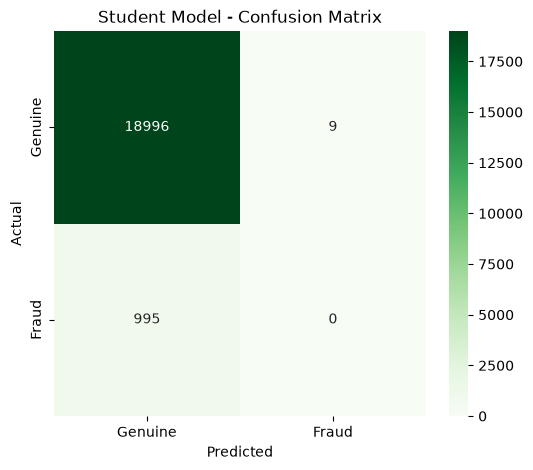

In [38]:
#Student Confusion Matrix
cm_student = confusion_matrix(
    y_test_np,
    student_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_student,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Genuine", "Fraud"],
    yticklabels=["Genuine", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Student Model - Confusion Matrix")

plt.show()

In [39]:
#Automatic Claim Routing
def route_claim(probability):

    if probability <= 0.30:
        return "Fast-Track Payout"

    elif probability <= 0.70:
        return "Standard Review"

    else:
        return "Fraud Investigation"

print(route_claim(0.15))
print(route_claim(0.55))
print(route_claim(0.90))

Fast-Track Payout
Standard Review
Fraud Investigation


In [40]:
#@title 🔍 Interactive Insurance Claim Fraud Predictor { run: "auto" }
# ============================================================
# Test Any New Insurance Claim (Interactive Form Inputs)
# ============================================================
import numpy as np
import pandas as pd
import torch
from scipy import sparse

# ------------------------------------------------------------
# 1. User Form Inputs (Edit these values or use the Colab UI form)
# ------------------------------------------------------------
customer_age = 35 #@param {type:"integer"}
claim_amount = 45000 #@param {type:"number"}
incident_severity = "Major Damage" #@param ["Minor Damage", "Total Loss", "Major Damage", "Trivial Damage"]
incident_type = "Single Vehicle Collision" #@param ["Single Vehicle Collision", "Vehicle Theft", "Multi-vehicle Collision", "Parked Car"]
collision_type = "Front Collision" #@param ["Front Collision", "Rear Collision", "Side Collision", "Unknown"]
authorities_contacted = "Police" #@param ["Police", "Fire", "Ambulance", "Other", "Unknown"]
bodily_injuries = 1 #@param {type:"slider", min:0, max:5, step:1}
witnesses = 0 #@param {type:"slider", min:0, max:5, step:1}
police_report_available = "YES" #@param ["YES", "NO", "Unknown"]

# ------------------------------------------------------------
# 2. Build the Complete Feature Vector from Baseline Template
# ------------------------------------------------------------
# Start with median/mode template from X_test so all 33 features are present
user_claim = X_test.iloc[0:1].copy()

# Override with the user's specific inputs
user_claim["customer_age"] = customer_age
user_claim["claim_amount"] = claim_amount
user_claim["incident_severity"] = incident_severity
user_claim["incident_type"] = incident_type
user_claim["collision_type"] = collision_type
user_claim["authorities_contacted"] = authorities_contacted
user_claim["bodily_injuries"] = bodily_injuries
user_claim["witnesses"] = witnesses
user_claim["police_report_available"] = police_report_available

# ------------------------------------------------------------
# 3. Preprocess the User Claim
# ------------------------------------------------------------
processed_input = preprocessor.transform(user_claim)

if sparse.issparse(processed_input):
    input_dense = processed_input.toarray().astype(np.float32)
else:
    input_dense = np.asarray(processed_input).astype(np.float32)

input_tensor = torch.tensor(input_dense, dtype=torch.float32).to(device)

# ------------------------------------------------------------
# 4. Predict Fraud Probability with PyTorch Student Model
# ------------------------------------------------------------
student.eval()
with torch.no_grad():
    logits = student(input_tensor)
    fraud_prob = torch.sigmoid(logits).item()
    routing_decision = route_claim(fraud_prob)

# ------------------------------------------------------------
# 5. Display Formatted Result Card
# ------------------------------------------------------------
print("\n" + "=" * 65)
print("                CLAIM ANALYSIS & FRAUD ASSESSMENT")
print("=" * 65)
print(f" Customer Age        : {customer_age} years")
print(f" Claim Amount        : ${claim_amount:,.2f}")
print(f" Incident Type       : {incident_type}")
print(f" Incident Severity   : {incident_severity}")
print(f" Collision Type      : {collision_type}")
print(f" Authorities Notified: {authorities_contacted}")
print(f" Witnesses / Report  : {witnesses} witness(es) | Police Report: {police_report_available}")
print("-" * 65)
print(f" 🎯 Fraud Probability: {fraud_prob:.2%}")
print(f" 🚦 Routing Decision : {routing_decision}")
print("=" * 65)
print("\n--- MODEL EVALUATION METRICS ---")
print("Accuracy :", teacher_accuracy)
print("Precision:", teacher_precision)
print("Recall   :", teacher_recall)
print("F1 Score :", teacher_f1)
print("=" * 65)



                CLAIM ANALYSIS & FRAUD ASSESSMENT
 Customer Age        : 35 years
 Claim Amount        : $45,000.00
 Incident Type       : Single Vehicle Collision
 Incident Severity   : Major Damage
 Collision Type      : Front Collision
 Authorities Notified: Police
 Witnesses / Report  : 0 witness(es) | Police Report: YES
-----------------------------------------------------------------
 🎯 Fraud Probability: 19.10%
 🚦 Routing Decision : Fast-Track Payout

--- MODEL EVALUATION METRICS ---
Accuracy : 0.8398
Precision: 0.05301497369486038
Recall   : 0.13165829145728644
F1 Score : 0.07559145989613388
